In [1]:
import numpy as np 
import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt
import seaborn as sns

from probjax.distributions.divergences.wasserstein import wasserstein_distance, sliced_wasserstein_distance, max_slice_wasserstein_distance
from probjax.distributions import Empirical, Independent, Gamma

In [126]:
data = jnp.array(np.load("data/data.npy"))
simulated_data = jnp.array(np.load("data/simulated_data.npy"))
simulated_dynamo = jnp.array(np.load("data/simulated_dynamo.npy"))

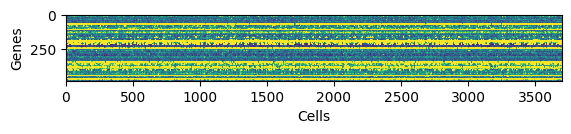

In [129]:
plt.imshow(data.T, vmax=1.)
plt.xlabel("Cells")
plt.ylabel("Genes")
plt.savefig("figures/real_data.png", dpi=300)

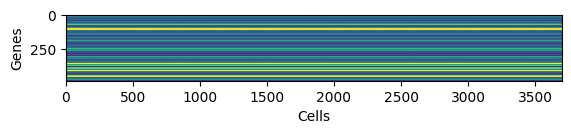

In [145]:
plt.imshow(simulated_data.T, vmin=0.,vmax=1.)
plt.xlabel("Cells")
plt.ylabel("Genes")
plt.savefig("figures/simulated_data.png", dpi=300)

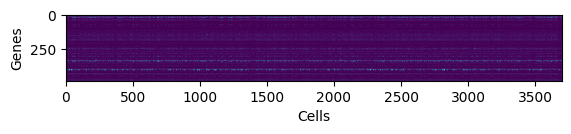

In [131]:
plt.imshow(simulated_dynamo.T,vmin=0.,vmax=1.)
plt.xlabel("Cells")
plt.ylabel("Genes")
plt.savefig("figures/simulated_dynamo.png", dpi=300)

In [132]:
alpha_real = jnp.mean(data, axis=0) + 1e-10
alpha_sim = jnp.mean(simulated_data, axis=0) + 1e-10

In [133]:
p0 = Independent(Empirical(data), 1)
p1 = Independent(Empirical(simulated_data), 1)
p2 = Independent(Empirical(simulated_dynamo), 1)
p3 = Independent(Gamma(alpha_real, 1.), 1)
#p4 = Independent(Gamma(alpha_sim, 1.), 1)

distributions = [p0, p1, p2, p3]

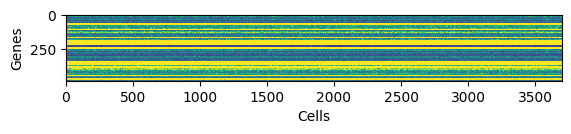

In [134]:
plt.imshow(p3.sample(jax.random.PRNGKey(0), (data.shape[0],)).T,vmax=1.)
plt.xlabel("Cells")
plt.ylabel("Genes")
plt.savefig("figures/dummy.png", dpi=300)

In [135]:
distances_w1 = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_w1 = wasserstein_distance(distributions[i], distributions[j], mc_samples=800, key=key,  order=1., epsilon=0.5)
        distances_w1 = distances_w1.at[i, j].set(distance_w1)
        
# Normalize with self distance and symmetrize

distances_w1 = distances_w1 - jnp.diag(distances_w1)[:, None] # Remove self similarity
distances_w1 = jnp.triu(distances_w1) + jnp.triu(distances_w1, k=1).T

In [136]:
distances_sliced_w1_more_slices = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=1500, key=key,  num_slices=10000, order=1.)
        distances_sliced_w1_more_slices = distances_sliced_w1_more_slices.at[i, j].set(distance_sliced_w1)
        
# Normalize with self distance and symmetrize
distances_sliced_w1_more_slices = distances_sliced_w1_more_slices - jnp.diag(distances_sliced_w1_more_slices)[:, None]
distances_sliced_w1_more_slices = jnp.triu(distances_sliced_w1_more_slices) + jnp.triu(distances_sliced_w1_more_slices, k=1).T

In [137]:
distances_sliced_w1_max_slices = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_sliced_w1 = max_slice_wasserstein_distance(distributions[i], distributions[j], mc_samples=1500, key=jax.random.PRNGKey(i), tol=1e-2, num_init=10)
        distances_sliced_w1_max_slices = distances_sliced_w1_max_slices.at[i, j].set(distance_sliced_w1)
        
# Normalize with self distance and symmetrize
distances_sliced_w1_max_slices = distances_sliced_w1_max_slices - jnp.diag(distances_sliced_w1_max_slices)[:, None]
distances_sliced_w1_max_slices = jnp.triu(distances_sliced_w1_max_slices) + jnp.triu(distances_sliced_w1_max_slices, k=1).T

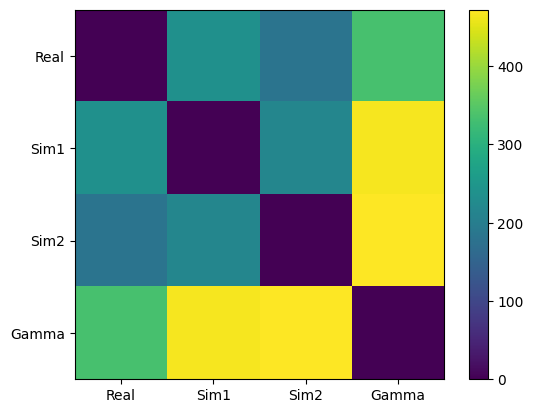

In [150]:
plt.imshow(distances_w1, vmin=0.)
plt.xticks(range(len(distributions)), ["Real", "Sim1", "Sim2", "Gamma"])
plt.yticks(range(len(distributions)), ["Real", "Sim1", "Sim2", "Gamma"])
plt.colorbar()
plt.savefig("figures/rna_w1.png", dpi=300)

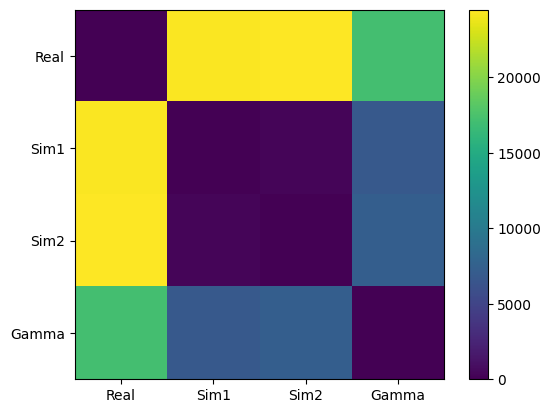

In [148]:
plt.imshow(distances_sliced_w1_max_slices, vmin=0.)
plt.xticks(range(len(distributions)), ["Real", "Sim1", "Sim2", "Gamma"])
plt.yticks(range(len(distributions)), ["Real", "Sim1", "Sim2", "Gamma"])
plt.colorbar()
plt.savefig("figures/rna_w1_max_sliced.png", dpi=300)

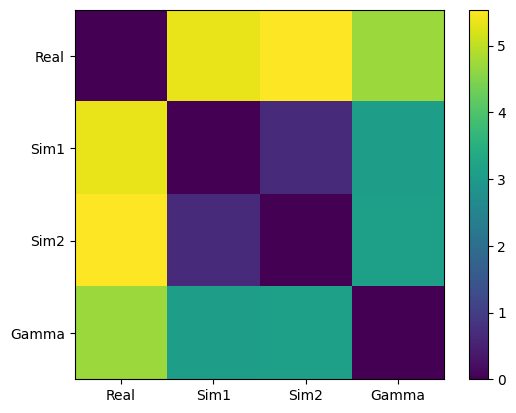

In [149]:
plt.imshow(distances_sliced_w1_more_slices, vmin=0.)
plt.xticks(range(len(distributions)), ["Real", "Sim1", "Sim2", "Gamma"])
plt.yticks(range(len(distributions)), ["Real", "Sim1", "Sim2", "Gamma"])
plt.colorbar()
plt.savefig("figures/rna_w1_sliced.png", dpi=300)

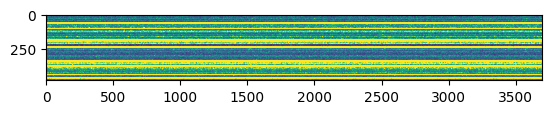

In [121]:
plt.imshow(p3.sample(jax.random.PRNGKey(0),(data.shape[0],)).T, vmax=1.)

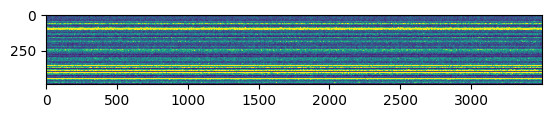

In [101]:
samples = p4.sample(jax.random.PRNGKey(0), (3500,))
plt.imshow(samples.T, vmax=1.)